
Using CIC mass assignment scheme
Time taken = 5.204 seconds


Computing power spectrum of the field...
Time to complete loop = 113.60
Time taken = 130.04 seconds


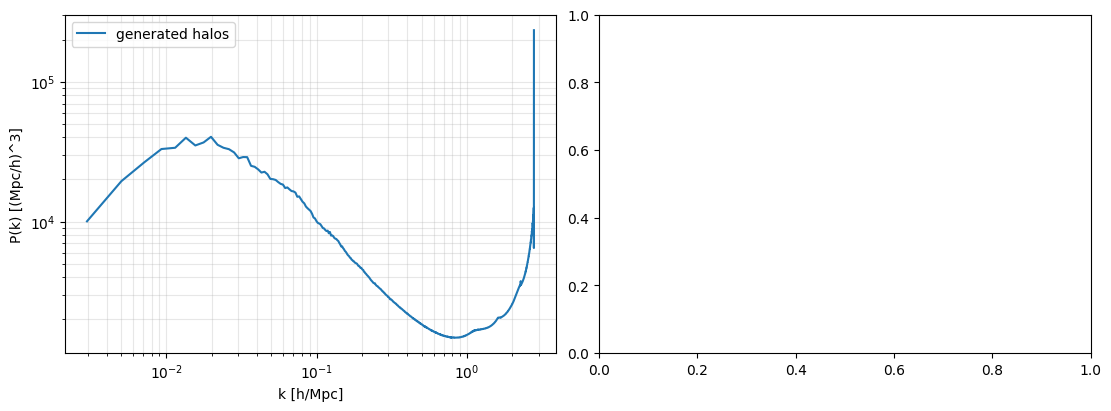

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import MAS_library as MASL
import Pk_library as PKL

sim_id = 0
BoxSize = 3*1000.0  # Mpc/h
grid = 3*512
MAS = 'CIC'
threads = 12

cat_file = f'/mnt/ceph/users/spandey/quijote_v2_gotham/IC_3gpc_test/generated_halo_cats/generated_halo_catalog_CV_0_3gpc_multigpu.npy'
# linpk_file = f'/mnt/ceph/users/spandey/discodj_runs/LH/{sim_id}/ICs/Pk_mm_z=0.000.txt'
# cosmo_file = f'/mnt/ceph/users/spandey/discodj_runs/LH/{sim_id}/ICs/Cosmo_params.dat'

halos = np.load(cat_file)
pos_h = halos[:, :3].astype(np.float32) % BoxSize
# cosmo = np.loadtxt(cosmo_file)
# print(f'sim {sim_id} cosmology [Om, Ob, h, ns, sigma8] = {cosmo}')
# print(f'Nhalos = {pos_h.shape[0]:,}')

delta_h = np.zeros((grid, grid, grid), dtype=np.float32)
MASL.MA(pos_h, delta_h, BoxSize, MAS, verbose=True)
delta_h /= delta_h.mean(dtype=np.float64)
delta_h -= 1.0

Pk_h = PKL.Pk(delta_h, BoxSize, axis=0, MAS=MAS, threads=threads, verbose=True)
k_h = Pk_h.k3D
P_hh = Pk_h.Pk[:, 0]
shot = BoxSize**3 / pos_h.shape[0]
P_hh_shot = P_hh - shot

# k_lin, P_lin = np.loadtxt(linpk_file, unpack=True)
# P_lin_at_h = np.exp(np.interp(np.log(k_h), np.log(k_lin), np.log(P_lin)))
# b_h = np.sqrt(np.clip(P_hh_shot / P_lin_at_h, 0, None))

fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
ax[0].loglog(k_h, P_hh, label='generated halos')
# ax[0].loglog(k_h, P_hh_shot, label='generated halos - shot')
# ax[0].loglog(k_lin, P_lin, '--', label='linear matter CAMB z=0')
ax[0].set_xlabel('k [h/Mpc]')
ax[0].set_ylabel('P(k) [(Mpc/h)^3]')
ax[0].legend()
ax[0].grid(alpha=0.3, which='both')

# ax[1].semilogx(k_h, b_h)
# ax[1].set_xlabel('k [h/Mpc]')
# ax[1].set_ylabel('sqrt((P_hh - 1/nbar) / P_lin)')
# ax[1].set_ylim(0, 10)
# ax[1].grid(alpha=0.3, which='both')

plt.show()


In [ ]:
from colossus.cosmology import cosmology
from colossus.halo import mass_so

def load_halo_catalog(isim, cosmo_params, snap_dir_base, snap_num, redshift, MSTAR_CUT):
    """Load and filter Rockstar halo catalog."""
    Om, Ob, h0, ns, sigma8 = cosmo_params
    
    # Set up colossus cosmology
    params = {
        'flat': True, 'H0': h0 * 100, 'Om0': Om,
        'Ob0': Ob, 'sigma8': sigma8, 'ns': ns
    }
    cosmology.setCosmology('myCosmo', persistence='', **params)
    
    # Load Rockstar catalog
    snapdir = f"{snap_dir_base}/{isim}"
    catalog_file = f"{snapdir}/out_{snap_num}_pid.list"
    
    with open(catalog_file, 'r') as f:
        header = f.readline().split()
    
    rockstar = np.loadtxt(catalog_file)
    
    # Extract properties
    pos = rockstar[:, header.index('X'):header.index('Z')+1]
    mass = rockstar[:, header.index('M200c')]
    lgMass = np.log10(mass).astype(np.float32)
    lgMass = np.clip(lgMass, 0, 15.7)
    
    vel = rockstar[:, header.index('VX'):header.index('VZ')+1]
    
    # Concentration
    Rhalo = (1 + redshift) * mass_so.M_to_R(mass, redshift, '200c')
    Rs = rockstar[:, header.index('Rs')]
    conc = Rhalo / Rs
    
    pid = rockstar[:, -1]
    
    # Stack properties: [lgM, vx, vy, vz, conc]
    props = np.column_stack((lgMass, vel, conc))
    
    # Filter: central halos above mass cut
    mask = (pid == -1) & (lgMass > MSTAR_CUT)
    
    return pos[mask].astype(np.float32), props[mask].astype(np.float32)
    


In [ ]:
redshift = 0.5
snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/fiducial_HR'
snap_num = 3
MSTAR_CUT = 12.7

pos_h_truth, props_h_truth = load_halo_catalog(0, [0.3175, 0.049, 0.6711, 0.9624, 0.834], snap_dir_base, snap_num, redshift, MSTAR_CUT)
grid_truth = 512
BoxSize_truth = 1000.

delta_h_truth = np.zeros((grid_truth, grid_truth, grid_truth), dtype=np.float32)
MASL.MA(pos_h_truth, delta_h_truth, BoxSize_truth, MAS, verbose=True)
delta_h_truth /= delta_h_truth.mean(dtype=np.float64)
delta_h_truth -= 1.0

Pk_h_truth = PKL.Pk(delta_h_truth, BoxSize_truth, axis=0, MAS=MAS, threads=threads, verbose=True)
k_h_truth = Pk_h_truth.k3D
P_hh_truth = Pk_h_truth.Pk[:, 0]



/tmp/ipykernel_3758092/3462983644.py:27: RuntimeWarning: divide by zero encountered in log10
  lgMass = np.log10(mass).astype(np.float32)



Using CIC mass assignment scheme
Time taken = 0.212 seconds


Computing power spectrum of the field...
Time to complete loop = 4.20
Time taken = 4.65 seconds


In [6]:
redshift = 0.5
snap_dir_base = '/mnt/ceph/users/spandey/Quijote/3Gpc/HR'
snap_num = 1
MSTAR_CUT = 12.7


pos_h_truth_3gpc, props_h_truth_3gpc = load_halo_catalog(0, [0.3175, 0.049, 0.6711, 0.9624, 0.834], snap_dir_base, snap_num, redshift, MSTAR_CUT)

grid_truth_3gpc = 3*512
BoxSize_truth_3gpc = 3*1000.

delta_h_truth_3gpc = np.zeros((grid_truth_3gpc, grid_truth_3gpc, grid_truth_3gpc), dtype=np.float32)
MASL.MA(pos_h_truth_3gpc, delta_h_truth_3gpc, BoxSize_truth_3gpc, MAS, verbose=True)
delta_h_truth_3gpc /= delta_h_truth_3gpc.mean(dtype=np.float64)
delta_h_truth_3gpc -= 1.0

Pk_h_truth_3gpc = PKL.Pk(delta_h_truth_3gpc, BoxSize_truth_3gpc, axis=0, MAS=MAS, threads=threads, verbose=True)
k_h_truth_3gpc = Pk_h_truth_3gpc.k3D
P_hh_truth_3gpc = Pk_h_truth_3gpc.Pk





/tmp/ipykernel_3758092/3462983644.py:27: RuntimeWarning: divide by zero encountered in log10
  lgMass = np.log10(mass).astype(np.float32)



Using CIC mass assignment scheme
Time taken = 5.921 seconds


Computing power spectrum of the field...
Time to complete loop = 113.18
Time taken = 129.02 seconds


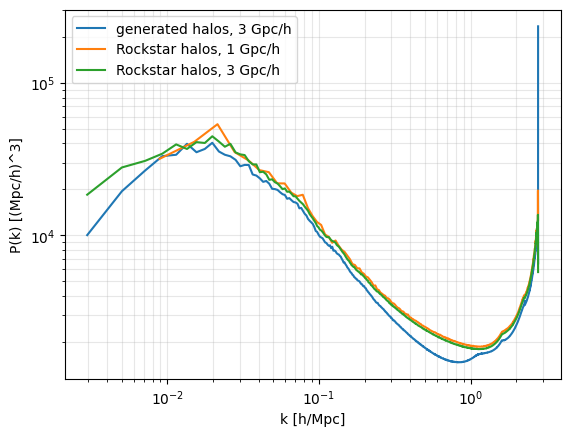

In [8]:
plt.figure()
plt.loglog(k_h, P_hh, label='generated halos, 3 Gpc/h')
plt.loglog(k_h_truth, P_hh_truth, label='Rockstar halos, 1 Gpc/h')
plt.loglog(k_h_truth_3gpc, P_hh_truth_3gpc[:, 0], label='Rockstar halos, 3 Gpc/h')
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) [(Mpc/h)^3]')
plt.legend()
plt.grid(alpha=0.3, which='both')




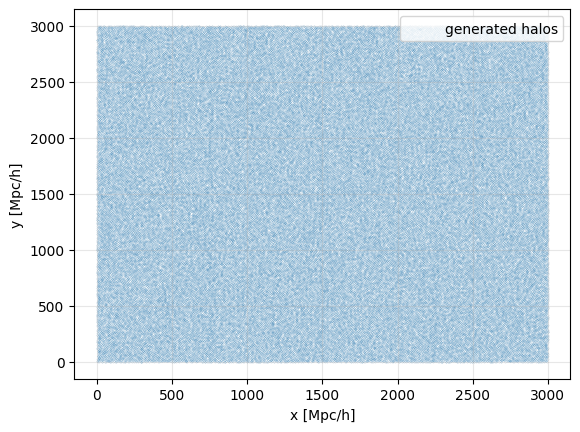

In [ ]:
plt.figure()
plt.scatter(pos_h[::100, 0], pos_h[::100, 1], s=0.01, alpha=0.5, label='generated halos')
plt.xlabel('x [Mpc/h]')
plt.ylabel('y [Mpc/h]')
plt.legend()
plt.grid(alpha=0.3, which='both')


